In [5]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans


In [2]:
image_path = "../runs/player_1.jpg"
image = cv2.imread(image_path)
# Convert the image from BGR to RGB
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

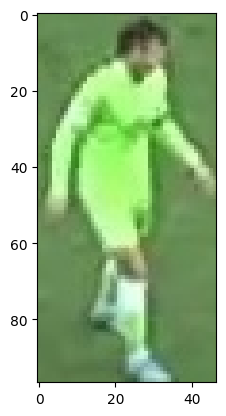

In [3]:
plt.imshow(image_rgb)

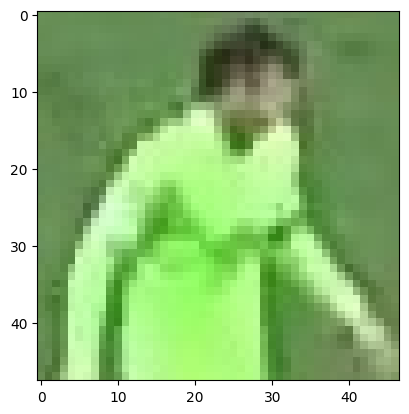

In [4]:
# take the top half of the image

top_half = image_rgb[:image_rgb.shape[0] // 2, :]
plt.imshow(top_half)

### Phân cụm hình ảnh thành hai cụm

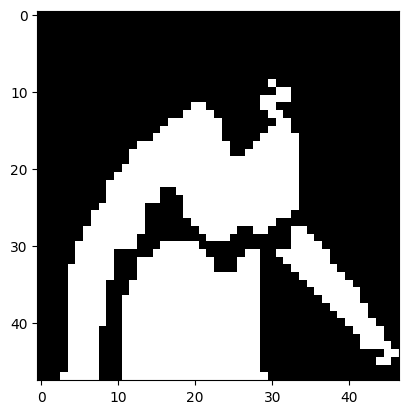

In [7]:
img2d = top_half.reshape(-1, 3)

# phân cụm kmeans
kmeans = KMeans(n_clusters=2, random_state=0).fit(img2d)

# lấy nhãn của cụm
labels = kmeans.labels_

# reshape nhãn về hình ảnh gốc
claustered_image = labels.reshape(top_half.shape[0], top_half.shape[1])

plt.imshow(claustered_image, cmap='gray')

In [8]:
conner_cluster = [claustered_image[0, 0], claustered_image[0, -1], claustered_image[-1, 0], claustered_image[-1, -1]]

none_player_cluster = max(set(conner_cluster), key=conner_cluster.count)

print(f"None player cluster: {none_player_cluster}")

None player cluster: 0


In [9]:
player_cluster = 1 - none_player_cluster
print(f"Player cluster: {player_cluster}")

Player cluster: 1


In [10]:
kmeans.cluster_centers_[player_cluster]

array([175.88571429, 242.56493506, 140.2974026 ])